In [1]:
# SENTIMENT ANALYSIS OF MOVIE REVIEWS

import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("../data/IMDB Dataset.csv")

df

,review,sentiment
0,Bromwell High is a cartoon comedy. It ran at t...,positive
1,Homelessness (or Houselessness as George Carli...,positive
2,Brilliant over-acting by Lesley Ann Warren. Be...,positive
3,This is easily the most underrated film inn th...,positive
4,This is not the typical Mel Brooks film. It wa...,positive
...,...,...
49995,I occasionally let my kids watch this garbage ...,negative
49996,When all we have anymore is pretty much realit...,negative
49997,The basic genre is a thriller intercut with an...,negative
49998,Four things intrigued me as to this film - fir...,negative


### check column names

In [2]:
df.columns

Index(['review', 'sentiment'], dtype='object')

### check dataset summary

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### chec missing/ null values

In [4]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

### check duplicates

In [5]:
df.duplicated().sum()

np.int64(418)

### Remove duplicates

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

In [7]:
df.shape

(49582, 2)

### Check sentimatic Distributions

In [8]:
print(df['sentiment'].value_counts())

sentiment
positive    24884
negative    24698
Name: count, dtype: int64


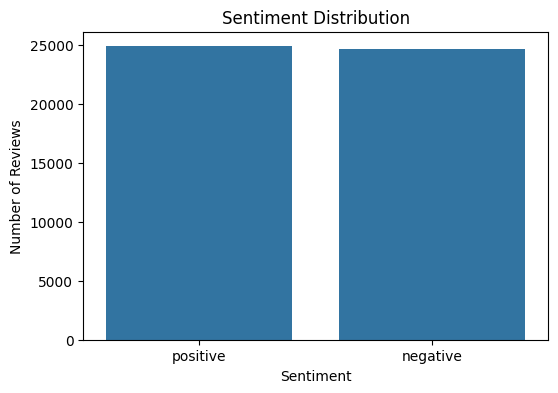

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

####
The dataset contains both positive and negative movie reviews. The sentiment distribution was visualized to check whether one class is significantly larger than the other.

## Text Preprocessing:  
Clean text data before it converted into numerical features.

In [10]:
# Converting text to lowercase
import re
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [11]:
# Test the cleaned function
sample_text = df['review'].iloc[0]
print("Original text:")
print(sample_text)
print("\nCleaned text:")
print(clean_text(sample_text))

Original text:
Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insightful students who can see right through their pathetic teachers' pomp, the pettiness of the whole situation, all remind me of the schools I knew and their students. When I saw the episode in which a student repeatedly tried to burn down the school, I immediately recalled ......... at .......... High. A classic line: INSPECTOR: I'm here to sack one of your teachers. STUDENT: Welcome to Bromwell High. I expect that many adults of my age think that Bromwell High is far fetched. What a pity that it isn't!

Cleaned text:
bromwell high is a cartoon comedy it ran at the same time as some other programs about school life such as teachers my years in the teaching profession lead me to 

### Applying the text cleaning function to all reviews in the dataset to create a new `cleaned_text` column.

In [12]:
df['cleaned_text'] = df['review'].apply(clean_text)

In [13]:
df[['review', 'cleaned_text']].head()

,review,cleaned_text
0,Bromwell High is a cartoon comedy. It ran at t...,bromwell high is a cartoon comedy it ran at th...
1,Homelessness (or Houselessness as George Carli...,homelessness or houselessness as george carlin...
2,Brilliant over-acting by Lesley Ann Warren. Be...,brilliant over acting by lesley ann warren bes...
3,This is easily the most underrated film inn th...,this is easily the most underrated film inn th...
4,This is not the typical Mel Brooks film. It wa...,this is not the typical mel brooks film it was...


### Lable Encoding:   
Convert text sentiments ('positive'/'negative') to numerical values (1/0) for machine learning models.

In [14]:
# Mapping sentiment labels to numerical values
df['label'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})

In [15]:
# check results 
df[['sentiment', 'label']].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,positive,1
4,positive,1


In [16]:
# check value counts
df['label'].value_counts()

label
1    24884
0    24698
Name: count, dtype: int64

## Train-Test Split

The cleaned reviews are used as input features, while the numerical sentiment labels are used as the target.
The dataset is split into 80% training data and 20% testing data.

In [17]:
X = df['cleaned_text']
y = df['label']

### Split Dataset

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39665
Testing samples: 9917


## Text Vectorization (TF-IDF)

Converting clean text into numerical features using TF-IDF (Term Frequency - Inverse Document Frequency).

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

In [22]:
X_train_tfidf = vectorizer.fit_transform(X_train) # always apply fit transformer on training daat
X_test_tfidf = vectorizer.transform(X_test) # always apply transformer on testing data

In [23]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (39665, 5000)
Testing TF-IDF shape: (9917, 5000)


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) was used to convert the text reviews into numerical features.

A maximum of 5,000 features was selected to keep the feature space manageable.

The vectorizer was fitted only on the training data and then used to transform the test data. This prevents information leakage from the test set into the model training pipeline.

## Model Training

Training a Logistic Regression model on the TF-IDF feature matrix. Logistic Regression serves as a strong baseline for binary text classification.

In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [25]:
model.fit(X_train_tfidf, y_train)
print("Model training completed successfully!")

Model training completed successfully!


## Model Prediction

The trained Logistic Regression model is now used to predict the sentiment of the unseen test reviews.

In [26]:
y_pred = model.predict(X_test_tfidf)

In [27]:
print("Actual labels:   ", y_test.values[:10])
print("Predicted labels:", y_pred[:10])

Actual labels:    [0 1 1 0 0 1 0 0 1 0]
Predicted labels: [0 0 1 0 0 1 0 0 1 1]


## Model Evaluation

Evaluating the model using Accuracy Score and F1 Score to measure classification performance.

In [28]:
from sklearn.metrics import accuracy_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.8962
Accuracy percentage: 89.62 %


In [29]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", round(f1, 4))

F1 Score: 0.8982


### Classification Report

Detailed classification report showing precision, recall, f1-score, and support for both classes.

In [30]:
from sklearn.metrics import classification_report
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Negative', 'Positive']
    )
)

              precision    recall  f1-score   support

    Negative       0.91      0.88      0.89      4940
    Positive       0.88      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



### Confusion Matrix 

The confusion matrix shows the number of correct and incorrect predictions for both sentiment classes.

The diagonal values represent correctly classified reviews, while the off-diagonal values represent incorrect predictions.

In [31]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[4348  592]
 [ 437 4540]]


### Check Heatmap visualisation

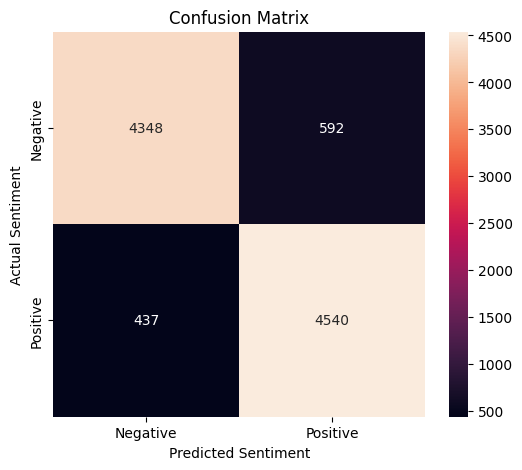

In [32]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")
plt.show()

### Now test our own sentences.

In [33]:
custom_sentences = [
    "This was the best movie I have ever watched.",
    "This movie was boring and a complete waste of time.",
    "I really enjoyed the story and the acting was excellent."
]

In [34]:
# Transform sentences using the same vectorizer
custom_tfidf = vectorizer.transform(custom_sentences)
# Predict sentiments
custom_predictions = model.predict(custom_tfidf)
# Map labels back to human-readable text
sentiment_labels = {
    0: "Negative",
    1: "Positive"
}
# Display results
for sentence, prediction in zip(custom_sentences, custom_predictions):
    print("Sentence:", sentence)
    print("Predicted sentiment:", sentiment_labels[prediction])
    print("-" * 60)

Sentence: This was the best movie I have ever watched.
Predicted sentiment: Positive
------------------------------------------------------------
Sentence: This movie was boring and a complete waste of time.
Predicted sentiment: Negative
------------------------------------------------------------
Sentence: I really enjoyed the story and the acting was excellent.
Predicted sentiment: Positive
------------------------------------------------------------


### Checking confidence scores (probabilities) for custom sentence predictions

In [35]:
custom_probabilities = model.predict_proba(custom_tfidf)
for sentence, prediction, probabilities in zip(
    custom_sentences,
    custom_predictions,
    custom_probabilities
):
    predicted_probability = max(probabilities) 
    print("Sentence:", sentence)
    print("Predicted sentiment:", sentiment_labels[prediction])
    print("Predicted probability:", round(predicted_probability * 100, 2), "%")
    print("-" * 60)

Sentence: This was the best movie I have ever watched.
Predicted sentiment: Positive
Predicted probability: 94.91 %
------------------------------------------------------------
Sentence: This movie was boring and a complete waste of time.
Predicted sentiment: Negative
Predicted probability: 99.98 %
------------------------------------------------------------
Sentence: I really enjoyed the story and the acting was excellent.
Predicted sentiment: Positive
Predicted probability: 99.66 %
------------------------------------------------------------


### Final Results

In [36]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Score': [accuracy, f1]
})
results

,Metric,Score
0,Accuracy,0.896239
1,F1 Score,0.898210


#  Final Summary

### Project Overview

This project developed a binary sentiment analysis model for classifying movie reviews as positive or negative.

### Approach

The project followed a complete NLP and machine learning pipeline:

1. Loaded a publicly available IMDB movie review dataset.
2. Inspected the dataset structure and sentiment distribution.
3. Checked for missing values and duplicate records.
4. Cleaned the review text by converting it to lowercase, removing HTML tags, special characters, and unnecessary whitespace.
5. Converted positive and negative sentiment labels into numerical values.
6. Split the dataset into training and testing sets.
7. Used TF-IDF to convert text into numerical features.
8. Trained a Logistic Regression classification model.
9. Evaluated the model using accuracy, F1-score, classification metrics, and a confusion matrix.
10. Tested the trained model on three custom sentences.

### Model Performance

The model achieved:

- Accuracy: **[WRITE ACTUAL RESULT HERE]**
- F1 Score: **[WRITE ACTUAL RESULT HERE]**

### Limitation

One limitation of the model is that TF-IDF with Logistic Regression does not fully understand the context of language. It may struggle with sarcasm, complex sentence structure, negation, or situations where the meaning of a word depends heavily on its context.

### Future Improvement

Future versions could use word embeddings or transformer-based NLP models to better capture contextual relationships between words and improve sentiment classification.